# 06c — Failure Case Analysis (BigEarthNet-S2 + CLIP Zero-Shot Labels)

**Mục đích:** Phân tích failure cases trên **BigEarthNet-S2** dataset.  
Do bản Kaggle không có metadata labels, ta sử dụng **CLIP zero-shot classification** để tự gán class cho mỗi patch.

### Pipeline
1. Load BigEarthNet patches (12 bands, `.tif` files)
2. **CLIP zero-shot**: Gán label cho mỗi patch bằng CLIP text-image similarity
3. Encode per-band embeddings (12 bands → 12×512)
4. Fuse via spectral retrieval pipeline
5. Identify R@1 failures & classify causes
6. Visualize results

### So sánh với NB 06/06b (EuroSAT)

| | EuroSAT | BigEarthNet (NB 06c) |
|---|---|---|
| Bands | 13 (incl. B10) | 12 (no B10/Cirrus) |
| Labels | Ground truth | CLIP zero-shot pseudo-labels |
| Classes | 10 single-label | 10 CLC classes (zero-shot) |
| Resolution | 64×64 | 120×120 |

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

#print(f"Project root: {PROJECT_ROOT}")

In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.size'] = 11

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

from collections import Counter

print(f"PyTorch {torch.__version__}")
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

PyTorch 2.0.1
Device: mps


## 1. Load CLIP Model

In [3]:
import open_clip

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-16", pretrained="laion2b_s34b_b88k"
)
clip_model = clip_model.to(DEVICE).eval()
tokenizer = open_clip.get_tokenizer("ViT-B-16")
print("CLIP ViT-B-16 loaded.")


CLIP ViT-B-16 loaded.


## 2. Load BigEarthNet-S2 Dataset

In [4]:
import logging
logging.basicConfig(level=logging.INFO)

from src.datasets.bigearth_loader import (
    BigEarthNetDataset,
    build_bigearth_subsets,
    BIGEARTH_BANDS,
    TOP10_CLASSES,
    CLASS_TEXT_MAP,
    NUM_BANDS,
)

BIGEARTH_ROOT = Path("/Volumes/Data/data/BigEarthNetS2/BigEarthNetS2")

# Giới hạn dataset
MAX_SAMPLES = 5000
QUERY_SIZE = 500
GALLERY_SIZE = 2000

print(f"BigEarthNet root: {BIGEARTH_ROOT}")
print(f"Config: max={MAX_SAMPLES}, query={QUERY_SIZE}, gallery={GALLERY_SIZE}")
print(f"Bands: {BIGEARTH_BANDS} ({NUM_BANDS} bands)")
print(f"\nTarget classes ({len(TOP10_CLASSES)}):")
for i, cls in enumerate(TOP10_CLASSES):
    print(f"  [{i}] {cls}")

BigEarthNet root: /Volumes/Data/data/BigEarthNetS2/BigEarthNetS2
Config: max=5000, query=500, gallery=2000
Bands: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12'] (12 bands)

Target classes (10):
  [0] Broad-leaved forest
  [1] Coniferous forest
  [2] Mixed forest
  [3] Arable land
  [4] Pastures
  [5] Complex cultivation patterns
  [6] Land principally occupied by agriculture, with significant areas of natural vegetation
  [7] Natural grassland and sparsely vegetated areas
  [8] Transitional woodland/shrub
  [9] Urban fabric


In [5]:
%%time

subsets = build_bigearth_subsets(
    root=BIGEARTH_ROOT,
    max_samples=MAX_SAMPLES,
    query_size=QUERY_SIZE,
    gallery_size=GALLERY_SIZE,
    use_cache=False,
    normalize=True,
    reflectance_scale=10000.0,
    clamp_range=(0.0, 1.0),
    seed=42,
    remove_snow_cloud_shadow=False,
)

query_ds = subsets["query"]
gallery_ds = subsets["gallery"]

print(f"\nQuery dataset:   {len(query_ds)} samples")
print(f"Gallery dataset: {len(gallery_ds)} samples")

# Quick check
sample = query_ds[0]
print(f"\nSample image shape: {sample['image'].shape}")
print(f"Image range: [{sample['image'].min():.4f}, {sample['image'].max():.4f}]")
print(f"Original labels (v2 = empty): {sample['label_names']}")


Query dataset:   500 samples
Gallery dataset: 2000 samples

Sample image shape: torch.Size([12, 120, 120])
Image range: [0.0035, 0.6519]
Original labels (v2 = empty): []
CPU times: user 5min 24s, sys: 24min 43s, total: 30min 7s
Wall time: 3h 14min 47s


## 3. CLIP Zero-Shot Classification

Gán pseudo-labels cho mỗi patch bằng cách:
1. Tạo RGB composite từ B04/B03/B02  
2. Resize lên 224×224 + CLIP normalize  
3. Encode image với CLIP  
4. So sánh cosine similarity với text embeddings của 10 classes  
5. Chọn class có similarity cao nhất

In [6]:
# Pre-compute text embeddings for all 10 classes
text_template = "A satellite image of {class_text}."
class_texts = [
    text_template.format(class_text=CLASS_TEXT_MAP.get(cls, cls))
    for cls in TOP10_CLASSES
]

print("Class text prompts:")
for i, txt in enumerate(class_texts):
    print(f"  [{i}] {txt}")

with torch.no_grad():
    text_tokens = tokenizer(class_texts).to(DEVICE)
    text_features = clip_model.encode_text(text_tokens)
    text_features = F.normalize(text_features, dim=-1)  # (10, 512)

print(f"\nText features shape: {text_features.shape}")

Class text prompts:
  [0] A satellite image of broad-leaved forest.
  [1] A satellite image of coniferous forest.
  [2] A satellite image of mixed forest.
  [3] A satellite image of arable land for agriculture.
  [4] A satellite image of pasture land.
  [5] A satellite image of complex cultivation patterns.
  [6] A satellite image of agricultural land with natural vegetation.
  [7] A satellite image of natural grassland and sparse vegetation.
  [8] A satellite image of transitional woodland and shrubs.
  [9] A satellite image of urban residential area.

Text features shape: torch.Size([10, 512])


In [7]:
CLIP_MEAN = torch.tensor([0.48145466, 0.45782750, 0.40821073]).view(3, 1, 1)
CLIP_STD  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3, 1, 1)

@torch.no_grad()
def clip_zero_shot_classify(dataset, clip_model, text_features, device, batch_size=16):
    """
    Assign pseudo-labels to all samples via CLIP zero-shot.
    
    For each patch:
      1. Extract RGB (B04=idx3, B03=idx2, B02=idx1)
      2. Resize to 224x224 + CLIP normalize
      3. Encode with CLIP image encoder
      4. Argmax cosine similarity with text features
    
    Returns: list of class names, list of confidence scores
    """
    labels = []
    confidences = []
    
    n = len(dataset)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch_imgs = []
        
        for i in range(start, end):
            sample = dataset[i]
            img = sample["image"]  # (12, 120, 120)
            
            # Extract RGB: B04=idx3, B03=idx2, B02=idx1
            rgb = img[[3, 2, 1]]  # (3, 120, 120)
            
            # Brightness stretch for satellite imagery
            rgb = torch.clamp(rgb * 3.5, 0, 1)
            
            # Resize to 224x224
            rgb = F.interpolate(
                rgb.unsqueeze(0), size=(224, 224),
                mode="bilinear", align_corners=False
            ).squeeze(0)  # (3, 224, 224)
            
            # CLIP normalize
            rgb = (rgb - CLIP_MEAN) / CLIP_STD
            batch_imgs.append(rgb)
        
        batch_tensor = torch.stack(batch_imgs).to(device)  # (B, 3, 224, 224)
        
        # Encode
        image_features = clip_model.encode_image(batch_tensor)
        image_features = F.normalize(image_features, dim=-1)  # (B, 512)
        
        # Similarity with text features
        similarity = image_features @ text_features.T  # (B, 10)
        
        # Argmax
        max_sim, max_idx = similarity.max(dim=-1)
        
        for j in range(len(batch_imgs)):
            labels.append(TOP10_CLASSES[max_idx[j].item()])
            confidences.append(max_sim[j].item())
        
        if (end) % 100 == 0 or end == n:
            print(f"  Classified {end}/{n}")
    
    return labels, confidences

print("Zero-shot classifier ready.")

Zero-shot classifier ready.


In [8]:
%%time

print("Classifying QUERY set...")
q_label_names, q_confidences = clip_zero_shot_classify(
    query_ds, clip_model, text_features, DEVICE
)

print("\nClassifying GALLERY set...")
g_label_names, g_confidences = clip_zero_shot_classify(
    gallery_ds, clip_model, text_features, DEVICE
)

print(f"\n=== Zero-Shot Classification Results ===")
print(f"Query labels distribution:")
q_dist = Counter(q_label_names)
for cls in TOP10_CLASSES:
    print(f"  {cls[:50]:<52s}: {q_dist.get(cls, 0):>4d}")

print(f"\nGallery labels distribution:")
g_dist = Counter(g_label_names)
for cls in TOP10_CLASSES:
    print(f"  {cls[:50]:<52s}: {g_dist.get(cls, 0):>4d}")

print(f"\nMean confidence: query={np.mean(q_confidences):.3f}, gallery={np.mean(g_confidences):.3f}")

Classifying QUERY set...
  Classified 400/500
  Classified 500/500

Classifying GALLERY set...
  Classified 400/2000
  Classified 800/2000
  Classified 1200/2000
  Classified 1600/2000
  Classified 2000/2000

=== Zero-Shot Classification Results ===
Query labels distribution:
  Broad-leaved forest                                 :    4
  Coniferous forest                                   :   46
  Mixed forest                                        :  146
  Arable land                                         :  108
  Pastures                                            :   66
  Complex cultivation patterns                        :   20
  Land principally occupied by agriculture, with sig  :   86
  Natural grassland and sparsely vegetated areas      :    2
  Transitional woodland/shrub                         :    8
  Urban fabric                                        :   14

Gallery labels distribution:
  Broad-leaved forest                                 :   37
  Coniferous forest   

## 4. Encode Per-Band Embeddings

In [9]:
from src.models.per_band_encoder import encode_multispectral_bands

def encode_dataset_bands(dataset, clip_model, device, label_names):
    """Encode all samples per-band, return embeddings and images."""
    n = len(dataset)
    embeddings_list = []
    images_list = []
    
    for i in range(n):
        sample = dataset[i]
        image = sample["image"]  # (12, 120, 120)
        
        band_embs = encode_multispectral_bands(
            image, clip_model, device=device,
            target_size=224, reflectance_scale=1.0,
            clamp_range=(0.0, 1.0),
        )  # (12, 512)
        
        embeddings_list.append(band_embs.cpu())
        images_list.append(image)
        
        if (i + 1) % 100 == 0:
            print(f"  Encoded {i+1}/{n}")
    
    embeddings = torch.stack(embeddings_list)
    return embeddings, images_list

print("Per-band encoder ready.")

Per-band encoder ready.


In [10]:
%%time

print("Encoding QUERY set per-band...")
q_embeddings, q_images = encode_dataset_bands(query_ds, clip_model, DEVICE, q_label_names)
print(f"Query embeddings: {q_embeddings.shape}")

print("\nEncoding GALLERY set per-band...")
g_embeddings, g_images = encode_dataset_bands(gallery_ds, clip_model, DEVICE, g_label_names)
print(f"Gallery embeddings: {g_embeddings.shape}")

Encoding QUERY set per-band...
  Encoded 100/500
  Encoded 200/500
  Encoded 300/500
  Encoded 400/500
  Encoded 500/500
Query embeddings: torch.Size([500, 12, 512])

Encoding GALLERY set per-band...
  Encoded 100/2000
  Encoded 200/2000
  Encoded 300/2000
  Encoded 400/2000
  Encoded 500/2000
  Encoded 600/2000
  Encoded 700/2000
  Encoded 800/2000
  Encoded 900/2000
  Encoded 1000/2000
  Encoded 1100/2000
  Encoded 1200/2000
  Encoded 1300/2000
  Encoded 1400/2000
  Encoded 1500/2000
  Encoded 1600/2000
  Encoded 1700/2000
  Encoded 1800/2000
  Encoded 1900/2000
  Encoded 2000/2000
Gallery embeddings: torch.Size([2000, 12, 512])
CPU times: user 3min 38s, sys: 1min 7s, total: 4min 46s
Wall time: 15min 59s


## 5. Fuse Embeddings via Retrieval Pipeline

In [11]:
from src.models.retrieval_pipeline import MultispectralRetrievalPipeline

pipeline = MultispectralRetrievalPipeline(
    sigma=0.5, num_steps=5, lr=0.01, lambda_m=0.1, k=5,
)

# Build class labels
unique_classes = sorted(set(q_label_names + g_label_names))
class_to_idx = {c: i for i, c in enumerate(unique_classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

print(f"Unique classes ({len(unique_classes)}):")
for cls in unique_classes:
    print(f"  {cls}")

# Per-class query embeddings using the SAME open_clip text encoder used above.
# Per Design Authority (PROJECT_CONTEXT.md Section 0, Rule 1):
# query_embedding MUST be the CLIP text embedding of the class, not mean(band_embeddings).
_text_features_cpu = text_features.detach().cpu()
class_query_embeddings = {}
for cls in unique_classes:
    if cls not in TOP10_CLASSES:
        raise ValueError(f"Pseudo-label class not found in TOP10_CLASSES: {cls}")
    class_query_embeddings[cls] = _text_features_cpu[TOP10_CLASSES.index(cls)]

print(f"\nBuilt CLIP text query embeddings for {len(class_query_embeddings)} classes")


Unique classes (10):
  Arable land
  Broad-leaved forest
  Complex cultivation patterns
  Coniferous forest
  Land principally occupied by agriculture, with significant areas of natural vegetation
  Mixed forest
  Natural grassland and sparsely vegetated areas
  Pastures
  Transitional woodland/shrub
  Urban fabric

Built CLIP text query embeddings for 10 classes


In [12]:
%%time

def fuse_set(embeddings, label_names, pipeline, class_query_embeddings):
    fused = []
    for i in range(len(label_names)):
        cls = label_names[i]
        query_emb = class_query_embeddings.get(cls)
        if query_emb is None:
            # Fallback for any unexpected class: encode text with the active open_clip model.
            class_text = CLASS_TEXT_MAP.get(cls, cls).lower()
            prompt = text_template.format(class_text=class_text)
            tokens = tokenizer([prompt]).to(DEVICE)
            with torch.no_grad():
                query_emb = clip_model.encode_text(tokens).float()
                query_emb = F.normalize(query_emb.squeeze(0), dim=0).cpu()
        result = pipeline.retrieve(
            band_embeddings=embeddings[i],
            query_embedding=query_emb,
        )
        fused.append(result.fused_embedding)
    return torch.stack(fused)

print("Fusing QUERY set...")
query_features = fuse_set(q_embeddings, q_label_names, pipeline, class_query_embeddings)
query_labels_int = torch.tensor([class_to_idx[ln] for ln in q_label_names])

print("Fusing GALLERY set...")
gallery_features = fuse_set(g_embeddings, g_label_names, pipeline, class_query_embeddings)
gallery_labels_int = torch.tensor([class_to_idx[ln] for ln in g_label_names])

print(f"\nQuery features:   {query_features.shape}")
print(f"Gallery features: {gallery_features.shape}")


Fusing QUERY set...
Fusing GALLERY set...

Query features:   torch.Size([500, 512])
Gallery features: torch.Size([2000, 512])
CPU times: user 2.21 s, sys: 293 ms, total: 2.5 s
Wall time: 2.26 s


## 6. Identify Failures (R@1 miss)

In [13]:
from src.utils.failure_analysis import (
    identify_failure_cases,
    classify_failure_causes,
    compute_failure_statistics,
    compute_class_embedding_stats,
    print_failure_summary,
    plot_failure_cause_distribution,
    plot_confusion_heatmap,
    FAILURE_CAUSES, FAILURE_CAUSE_LABELS,
)

# Use patch names as image_paths
q_paths = [query_ds[i]["patch_name"] for i in range(len(query_ds))]

failures, summary = identify_failure_cases(
    query_features=query_features,
    query_labels=query_labels_int,
    gallery_features=gallery_features,
    gallery_labels=gallery_labels_int,
    label_names=q_label_names,
    idx_to_class=idx_to_class,
    threshold_rank=1,
    image_paths=q_paths,
)

print(f"=== Retrieval Summary (BigEarthNet-S2) ===")
print(f"Total queries:  {summary['total_queries']}")
print(f"R@1 hits:       {summary['total_hits']} ({summary['hit_rate']*100:.1f}%)")
print(f"R@1 failures:   {summary['total_failures']} ({summary['failure_rate']*100:.1f}%)")

=== Retrieval Summary (BigEarthNet-S2) ===
Total queries:  500
R@1 hits:       239 (47.8%)
R@1 failures:   261 (52.2%)


## 7. Classify Failure Causes (with raw pixel data)

In [14]:
# Prepare failure data
failure_images = [q_images[fc.sample_index] for fc in failures]
failure_band_embs = [q_embeddings[fc.sample_index] for fc in failures]

print(f"Failure images: {len(failure_images)}")
if failure_images:
    print(f"Image shape: {failure_images[0].shape}")
    print(f"Embedding shape: {failure_band_embs[0].shape}")

# Class stats: use gallery as the reference population for failure-cause heuristics.
# This replaces the old aggregate variables from earlier notebooks.
reference_embeddings = g_embeddings
reference_label_names = g_label_names
centroids, stds = compute_class_embedding_stats(reference_embeddings, reference_label_names)
gallery_class_dist = Counter(g_label_names)

print(f"\nClass embedding stats built from gallery reference set: {reference_embeddings.shape}")
missing_stats = sorted(set(q_label_names) - set(centroids.keys()))
if missing_stats:
    print(f"Warning: no gallery centroid for classes: {missing_stats}")

print(f"\nGallery class distribution:")
for cls in sorted(gallery_class_dist.keys()):
    print(f"  {cls[:50]:<52s}: {gallery_class_dist[cls]}")


Failure images: 261
Image shape: torch.Size([12, 120, 120])
Embedding shape: torch.Size([12, 512])

Class embedding stats built from gallery reference set: torch.Size([2000, 12, 512])

Gallery class distribution:
  Arable land                                         : 422
  Broad-leaved forest                                 : 37
  Complex cultivation patterns                        : 70
  Coniferous forest                                   : 146
  Land principally occupied by agriculture, with sig  : 367
  Mixed forest                                        : 527
  Natural grassland and sparsely vegetated areas      : 8
  Pastures                                            : 307
  Transitional woodland/shrub                         : 31
  Urban fabric                                        : 85


In [15]:
# Diagnostics for first few failures
print("=== Pre-classification diagnostics (first 5 failures) ===")
for i, fc in enumerate(failures[:5]):
    img = failure_images[i]
    emb = failure_band_embs[i]
    cls = fc.true_label
    
    print(f"\n  [{i}] True={cls[:40]}, Pred={fc.predicted_label[:40]}")
    if img is not None:
        # BigEarthNet: B09 at index 9 (Water Vapor)
        b09 = img[9].mean().item()
        band_means = img.mean(dim=(1, 2))
        band_stds = img.std(dim=(1, 2))
        cv = (band_stds / (band_means + 1e-8)).mean().item()
        print(f"    B09(WV)={b09:.4f} (thr=0.25), No B10 in BigEarthNet")
        print(f"    Spatial CV={cv:.4f} (thr=0.70)")
    
    if cls in centroids:
        sample_mean = emb.mean(dim=0)
        dist = torch.norm(sample_mean - centroids[cls]).item()
        zscore = dist / max(stds[cls], 1e-8)
        print(f"    Centroid dist={dist:.4f}, z-score={zscore:.2f} (thr=1.5)")

=== Pre-classification diagnostics (first 5 failures) ===

  [0] True=Land principally occupied by agriculture, Pred=Mixed forest
    B09(WV)=0.2073 (thr=0.25), No B10 in BigEarthNet
    Spatial CV=0.3068 (thr=0.70)
    Centroid dist=0.2733, z-score=4.64 (thr=1.5)

  [1] True=Pastures, Pred=Broad-leaved forest
    B09(WV)=0.0163 (thr=0.25), No B10 in BigEarthNet
    Spatial CV=0.0857 (thr=0.70)
    Centroid dist=0.3585, z-score=2.62 (thr=1.5)

  [2] True=Pastures, Pred=Broad-leaved forest
    B09(WV)=0.0126 (thr=0.25), No B10 in BigEarthNet
    Spatial CV=0.0804 (thr=0.70)
    Centroid dist=0.3964, z-score=2.90 (thr=1.5)

  [3] True=Pastures, Pred=Land principally occupied by agriculture
    B09(WV)=0.2244 (thr=0.25), No B10 in BigEarthNet
    Spatial CV=0.2536 (thr=0.70)
    Centroid dist=0.2340, z-score=1.71 (thr=1.5)

  [4] True=Coniferous forest, Pred=Mixed forest
    B09(WV)=0.2834 (thr=0.25), No B10 in BigEarthNet
    Spatial CV=0.1690 (thr=0.70)
    Centroid dist=0.3395, z-score

In [16]:
# Classify causes
failures = classify_failure_causes(
    failures,
    images=failure_images,
    band_embeddings=failure_band_embs,
    class_distribution=dict(gallery_class_dist),
    class_centroids=centroids,
    class_stds=stds,
    cirrus_threshold=0.15,
    wv_threshold=0.25,
    entropy_threshold=0.7,
    rare_percentile=20.0,
    deviation_threshold=1.5,
)

cause_counts = Counter(fc.failure_cause for fc in failures)
print("=" * 60)
print("  FAILURE CAUSE BREAKDOWN (BigEarthNet-S2)")
print("=" * 60)
for cause in FAILURE_CAUSES:
    count = cause_counts.get(cause, 0)
    pct = count / max(len(failures), 1) * 100
    label = FAILURE_CAUSE_LABELS[cause]
    print(f"  {label:20s}: {count:4d} ({pct:5.1f}%)")
print(f"  {'TOTAL':20s}: {len(failures):4d}")

  FAILURE CAUSE BREAKDOWN (BigEarthNet-S2)
  Cloud Cover         :    0 (  0.0%)
  Mixed Scene         :    9 (  3.4%)
  Rare Class          :    0 (  0.0%)
  Seasonal Variation  :  252 ( 96.6%)
  TOTAL               :  261


## 8. Band Attributions

In [17]:
from src.models.band_attribution import compute_band_attribution

failure_attributions = []
for i, fc in enumerate(failures):
    cls = fc.true_label
    query_emb = class_query_embeddings.get(cls)
    band_emb = failure_band_embs[i]
    
    if query_emb is not None:
        attr = compute_band_attribution(
            band_embeddings=band_emb,
            query_embedding=query_emb,
            sigma=0.5,
        )
        failure_attributions.append(attr.normalized_attribution.numpy())
        fc.band_attribution = attr.normalized_attribution.numpy()
    else:
        failure_attributions.append(None)

print(f"Attributions computed: {sum(1 for a in failure_attributions if a is not None)}/{len(failures)}")

Attributions computed: 261/261


## 9. Statistics & Visualizations

In [18]:
result = compute_failure_statistics(
    failures,
    class_names=unique_classes,
    total_samples=len(q_label_names),
)

report_text = print_failure_summary(result)

  FAILURE CASE ANALYSIS SUMMARY

  Total queries:   500
  Total failures:  261
  Failure rate:    52.2%
  Threshold:       R@1 miss

------------------------------------------------------------------------
  FAILURE CAUSE BREAKDOWN
------------------------------------------------------------------------
  Cloud Cover              0  (  0.0%)  Classes: 
  Mixed Scene              9  (  3.4%)  Classes: Mixed forest
  Rare Class               0  (  0.0%)  Classes: 
  Seasonal Variation     252  ( 96.6%)  Classes: Arable land, Broad-leaved forest, Complex cultivation patterns, Coniferous forest, Land principally occupied by agriculture, with significant areas of natural vegetation, ...

------------------------------------------------------------------------
  PER-CLASS FAILURE DETAILS
------------------------------------------------------------------------

  ▸ Arable land
    Failures: 30, Avg rank: 9.1, Mean AP: 0.306
    Confused with: Land principally occupied by agriculture, with sig

Saved: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis_bigearth/failure_cause_distribution.png


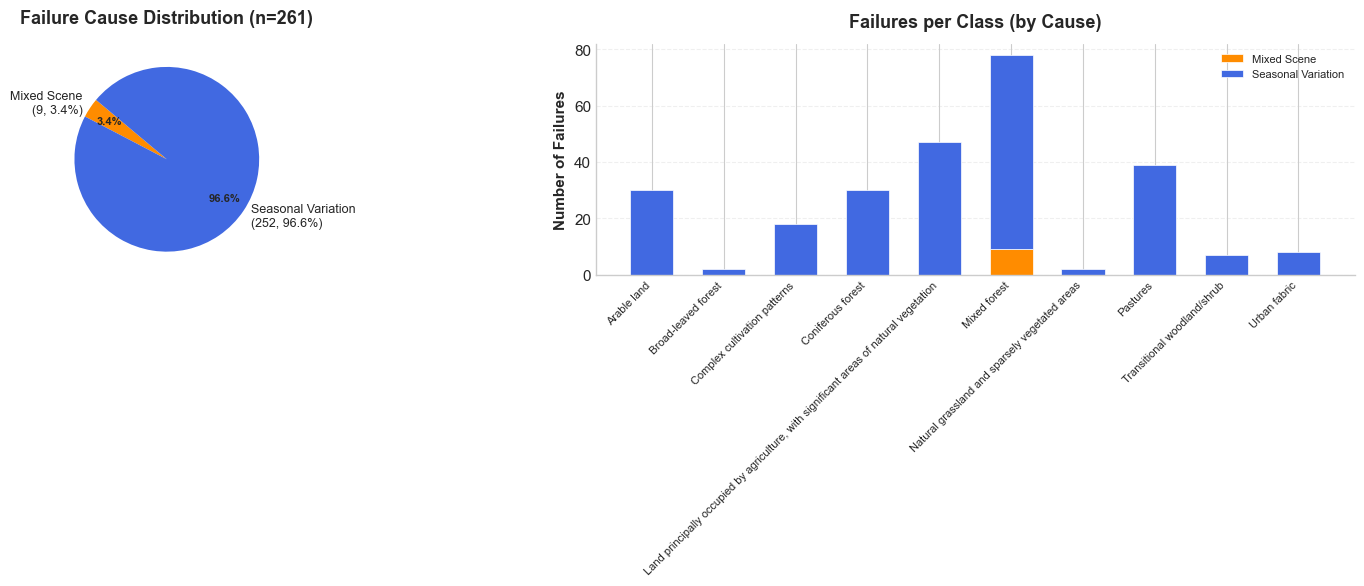

In [19]:
save_dir = PROJECT_ROOT / "results" / "failure_analysis_bigearth"
save_dir.mkdir(parents=True, exist_ok=True)

# Cause distribution
fig_dist, _ = plot_failure_cause_distribution(
    result, figsize=(16, 6),
    save_path=str(save_dir / "failure_cause_distribution.png"),
)
plt.show()

Saved: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis_bigearth/failure_confusion_matrix.png


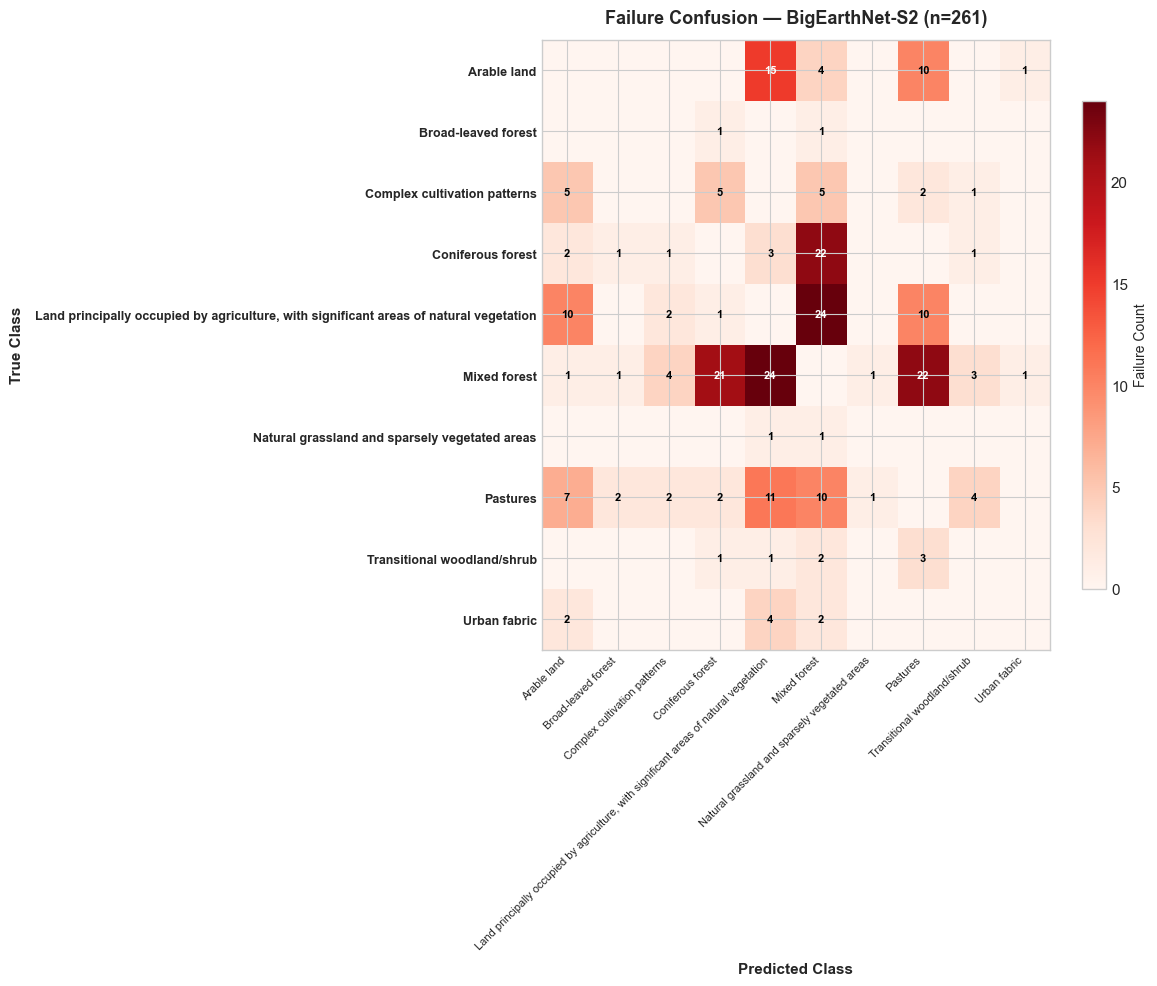

In [20]:
# Confusion matrix
fig_conf, _ = plot_confusion_heatmap(
    failures,
    class_names=unique_classes,
    figsize=(12, 10),
    save_path=str(save_dir / "failure_confusion_matrix.png"),
    title=f"Failure Confusion — BigEarthNet-S2 (n={len(failures)})",
)
plt.show()

## 10. Failure Gallery (BigEarthNet 12-band RGB)

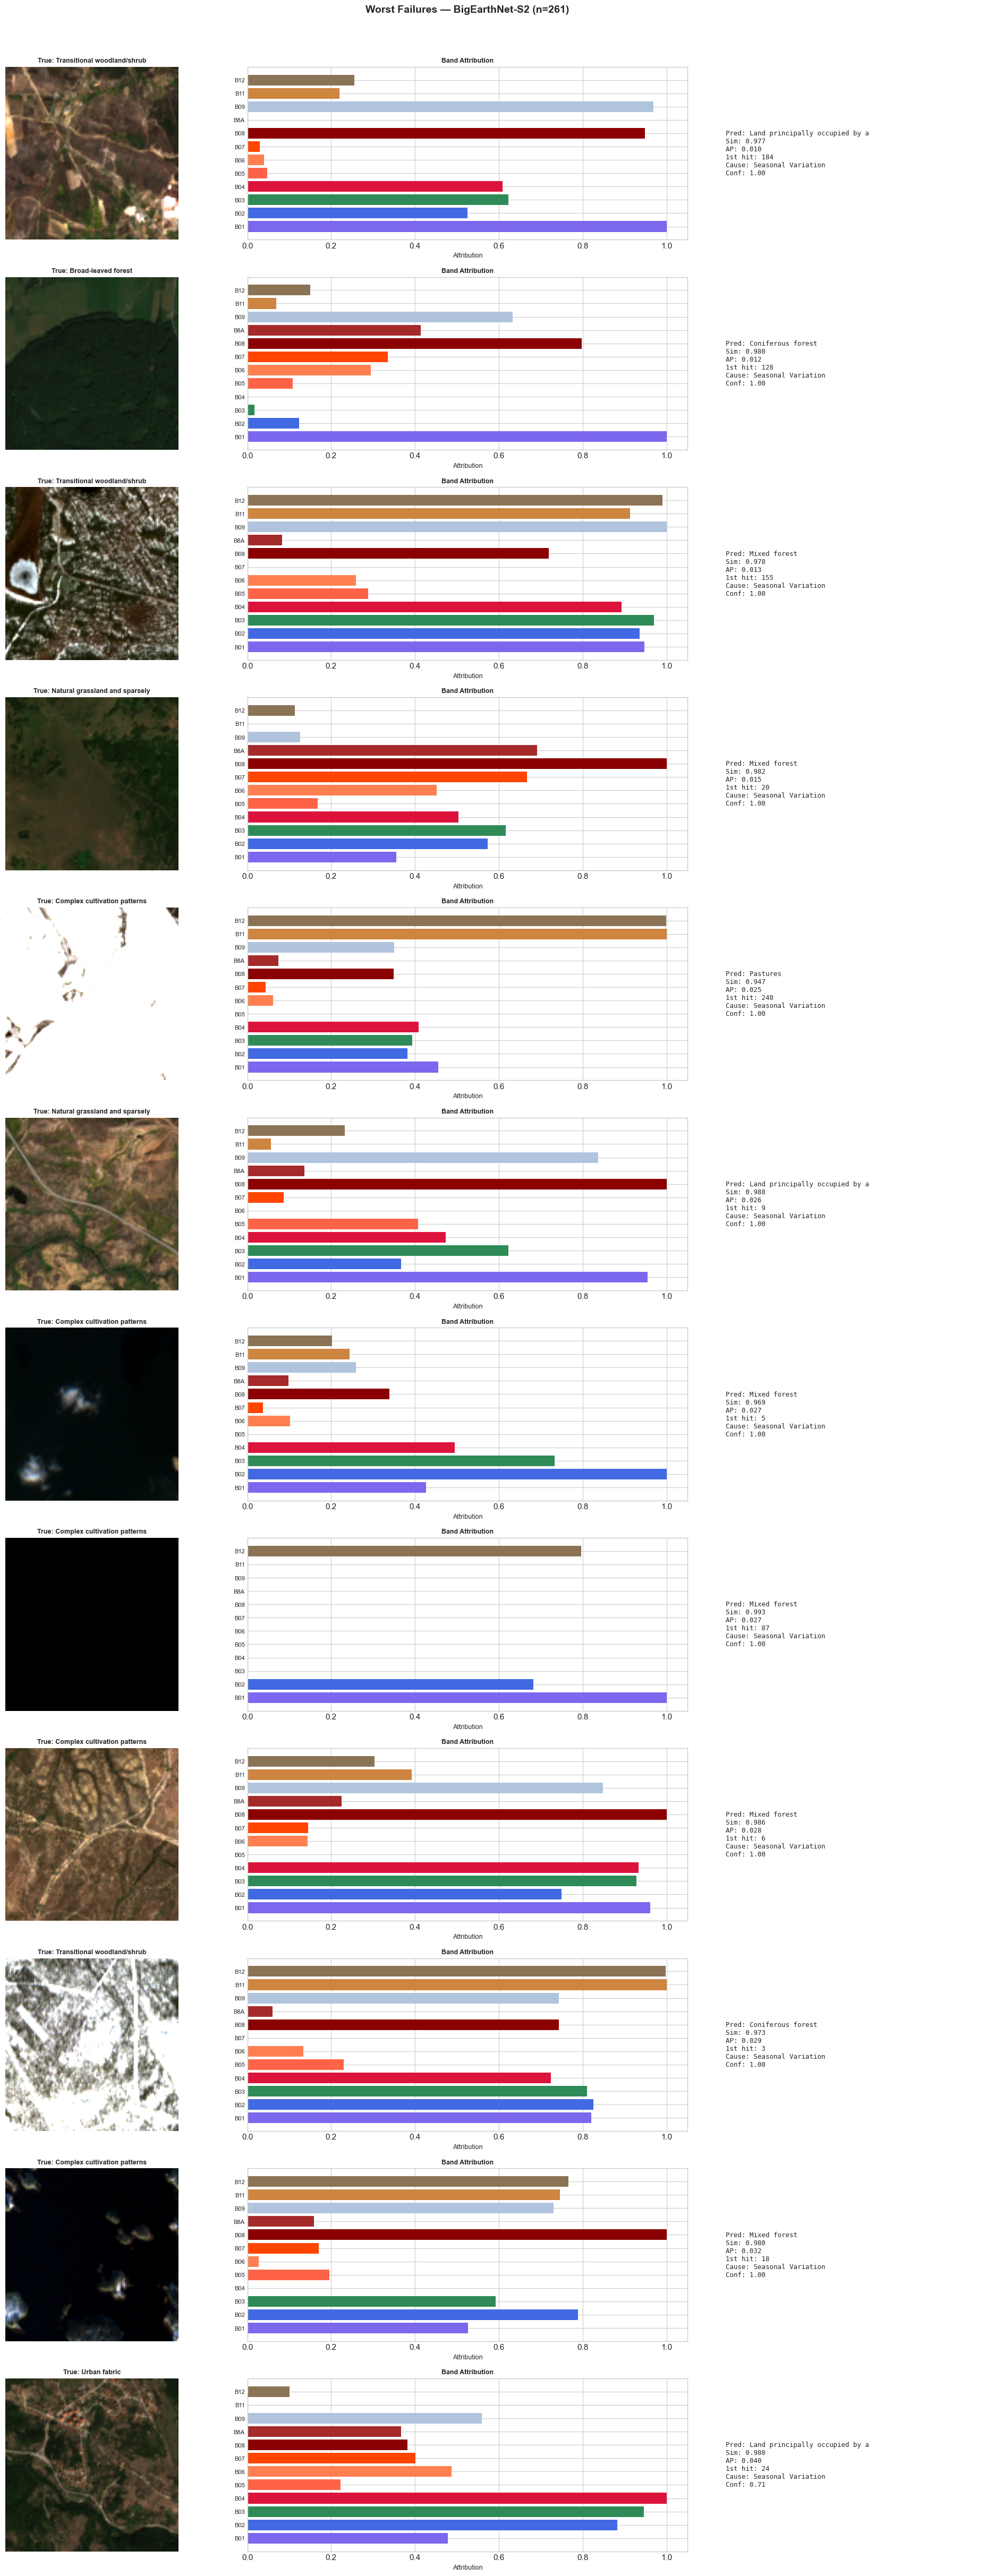

In [21]:
# Sort by AP (worst first)
sorted_idx = sorted(range(len(failures)), key=lambda i: failures[i].average_precision)
n_show = min(12, len(sorted_idx))

if n_show > 0:
    fig, axes = plt.subplots(n_show, 3, figsize=(20, 4 * n_show),
                              gridspec_kw={"width_ratios": [1, 1.5, 1]})
    if n_show == 1:
        axes = axes.reshape(1, -1)

    band_colors = [
        "#7B68EE", "#4169E1", "#2E8B57", "#DC143C",
        "#FF6347", "#FF7F50", "#FF4500", "#8B0000",
        "#A52A2A", "#B0C4DE", "#CD853F", "#8B7355",
    ]

    for row in range(n_show):
        si = sorted_idx[row]
        fc = failures[si]
        img = failure_images[si]
        attr = failure_attributions[si]
        
        ax_rgb, ax_attr, ax_info = axes[row]
        
        # RGB: B04=3, B03=2, B02=1
        if img is not None and img.shape[0] >= 4:
            rgb = img[[3, 2, 1]].numpy()
            rgb = np.clip(rgb * 3.5, 0, 1)
            rgb = np.transpose(rgb, (1, 2, 0))
            ax_rgb.imshow(rgb)
        ax_rgb.set_title(f"True: {fc.true_label[:30]}", fontsize=9, fontweight="bold")
        ax_rgb.axis("off")
        
        # Attribution bars
        if attr is not None:
            y_pos = np.arange(len(BIGEARTH_BANDS))
            ax_attr.barh(y_pos, attr[:len(BIGEARTH_BANDS)],
                        color=band_colors[:len(BIGEARTH_BANDS)])
            ax_attr.set_yticks(y_pos)
            ax_attr.set_yticklabels(BIGEARTH_BANDS, fontsize=8)
            ax_attr.set_xlabel("Attribution", fontsize=9)
            ax_attr.set_title("Band Attribution", fontsize=9, fontweight="bold")
        else:
            ax_attr.text(0.5, 0.5, "N/A", ha="center", va="center")
            ax_attr.axis("off")
        
        # Info
        info = (f"Pred: {fc.predicted_label[:30]}\n"
                f"Sim: {fc.similarity_score:.3f}\n"
                f"AP: {fc.average_precision:.3f}\n"
                f"1st hit: {fc.first_hit_rank or 'never'}\n"
                f"Cause: {FAILURE_CAUSE_LABELS.get(fc.failure_cause, fc.failure_cause)}\n"
                f"Conf: {fc.cause_confidence:.2f}")
        ax_info.text(0.1, 0.5, info, fontsize=9, va="center",
                     fontfamily="monospace", transform=ax_info.transAxes)
        ax_info.axis("off")

    fig.suptitle(f"Worst Failures — BigEarthNet-S2 (n={len(failures)})",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    fig.savefig(save_dir / "failure_gallery.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No failures to display!")

## 11. Save Results

In [22]:
import csv

# Failure cases CSV
csv_path = save_dir / "failure_cases.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["sample_index", "true_label", "predicted_label",
                     "similarity", "first_hit_rank", "average_precision",
                     "failure_cause", "cause_confidence", "patch_name"])
    for fc in failures:
        writer.writerow([
            fc.sample_index, fc.true_label, fc.predicted_label,
            f"{fc.similarity_score:.4f}",
            fc.first_hit_rank if fc.first_hit_rank else "inf",
            f"{fc.average_precision:.4f}",
            fc.failure_cause, f"{fc.cause_confidence:.3f}",
            fc.image_path or "",
        ])
#print(f"Saved {len(failures)} failures to {csv_path}")

# Summary
with open(save_dir / "failure_summary.txt", "w") as f:
    f.write(report_text)
print(f"Saved summary")

# Cause stats CSV
with open(save_dir / "cause_statistics.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["cause", "count", "percentage", "affected_classes", "avg_confidence"])
    for cause in FAILURE_CAUSES:
        s = result.per_cause_stats[cause]
        writer.writerow([FAILURE_CAUSE_LABELS[cause], s["count"],
                        f"{s['percentage']:.1f}",
                        "; ".join(s["affected_classes"]),
                        f"{s['avg_confidence']:.3f}"])
print(f"Saved cause statistics")

Saved summary
Saved cause statistics


In [23]:
print("\n" + "=" * 60)
print("  NB 06c — BigEarthNet-S2 Failure Analysis COMPLETE")
print("=" * 60)
print(f"\nDataset: BigEarthNet-S2 (Kaggle subset)")
print(f"Labels: CLIP zero-shot pseudo-labels")
print(f"Bands: {NUM_BANDS}, Classes: {len(unique_classes)}")
print(f"Query: {len(q_label_names)}, Gallery: {len(g_label_names)}")
print(f"Failure rate: {result.failure_rate*100:.1f}%")
#print(f"\nOutputs: {save_dir}/")


  NB 06c — BigEarthNet-S2 Failure Analysis COMPLETE

Dataset: BigEarthNet-S2 (Kaggle subset)
Labels: CLIP zero-shot pseudo-labels
Bands: 12, Classes: 10
Query: 500, Gallery: 2000
Failure rate: 52.2%
